In [1]:
import numpy as np
import pandas as pd
import os

In [2]:
print(os.listdir("dataset"))

['single_prediction', 'test', 'Testing_set.csv', 'train', 'Training_set.csv']


In [3]:
print(len(os.listdir("dataset/train")))

6499


In [4]:
print(len(os.listdir("dataset/test")))

2786


In [5]:
train_df=pd.read_csv("dataset/Training_set.csv")
test_df=pd.read_csv("dataset/Testing_set.csv")

In [6]:
train_df.head()

,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART


In [7]:
test_df.head()

,filename
0,Image_1.jpg
1,Image_2.jpg
2,Image_3.jpg
3,Image_4.jpg
4,Image_5.jpg


In [8]:
import tensorflow as tf
import keras

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
train_datagen=ImageDataGenerator(rescale=1/255)

In [11]:
training_set=train_datagen.flow_from_dataframe(dataframe=train_df,directory="dataset/train",x_col="filename",y_col="label",target_size=(64,64),batch_size=32,class_mode="categorical",shuffle=True)

Found 6499 validated image filenames belonging to 75 classes.


In [12]:
test_datagen=ImageDataGenerator(rescale=1/255)

In [13]:
testing_set=test_datagen.flow_from_dataframe(dataframe=test_df,directory="dataset/test",x_col="filename",target_size=(64,64),batch_size=32,class_mode=None,shuffle=False)

Found 2786 validated image filenames.


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split

train_df = pd.read_csv("dataset/Training_set.csv")

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

Training images: 5199
Validation images: 1300


In [15]:
val_datagen = ImageDataGenerator(rescale=1/255)

In [16]:
validation_set = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory="dataset/train",
    x_col="filename",
    y_col="label",
    target_size=(64,64),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 1300 validated image filenames belonging to 75 classes.


In [17]:
from keras.models import Sequential
classifier=Sequential()

In [18]:
from keras.layers import Conv2D
classifier.add(Conv2D(input_shape=[64,64,3],
                      filters=32,kernel_size=3,
                      activation="relu"))

C:\Users\LoQ\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
from keras.layers import MaxPooling2D
classifier.add(MaxPooling2D(pool_size=2,strides=2))

In [20]:
from keras.layers import Conv2D
classifier.add(Conv2D(input_shape=[64,64,3],
                      filters=32,kernel_size=3,
                      activation="relu"))

In [21]:
from keras.layers import MaxPooling2D
classifier.add(MaxPooling2D(pool_size=2,strides=2))

In [22]:
from keras.layers import Flatten
classifier.add(Flatten())

In [23]:
from keras.layers import Dense
classifier.add(Dense(units=128,activation="relu"))
classifier.add(Dense(len(training_set.class_indices), activation="softmax"))

In [24]:
classifier.compile(optimizer="adam",
                   loss="categorical_crossentropy",
                   metrics=["accuracy"])

In [25]:
classifier.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 24s 108ms/step - accuracy: 0.1406 - loss: 3.5346 - val_accuracy: 0.3469 - val_loss: 2.4765
Epoch 2/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - accuracy: 0.4248 - loss: 2.1544 - val_accuracy: 0.5331 - val_loss: 1.7037
Epoch 3/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - accuracy: 0.5749 - loss: 1.5329 - val_accuracy: 0.6446 - val_loss: 1.2809
Epoch 4/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 21s 101ms/step - accuracy: 0.6907 - loss: 1.0898 - val_accuracy: 0.8031 - val_loss: 0.7262
Epoch 5/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 27s 131ms/step - accuracy: 0.7974 - loss: 0.7159 - val_accuracy: 0.8815 - val_loss: 0.4673
Epoch 6/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 37s 183ms/step - accuracy: 0.8689 - loss: 0.4571 - val_accuracy: 0.9377 - val_loss: 0.2920
Epoch 7/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - accuracy: 0.9311 - loss: 0.2606 - val_accuracy: 0.9577 - val_loss: 0.1689
Epoch 8/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - accuracy: 0.9609 - loss: 0.15

In [27]:
import numpy as np
from tensorflow.keras.utils import load_img,img_to_array

In [28]:
test_image=load_img("dataset/single_prediction/butterfly.jpeg",
                    target_size=(64,64))

In [29]:
test_image=img_to_array(test_image)

In [30]:
test_image=test_image/255.0

In [31]:
test_image=np.expand_dims(test_image,axis=0)

In [32]:
result=classifier.predict(test_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step


In [33]:
predicted_class_index=np.argmax(result[0])

In [34]:
class_names=list(training_set.class_indices.keys())

In [35]:
predicted_class=class_names[predicted_class_index]

In [36]:
confidence=np.max(result[0])*100

In [37]:
print("Predicted butterfly:",predicted_class)
print("Confidence:",confidence, "%")

Predicted butterfly: BLUE MORPHO
Confidence: 94.07647 %


In [38]:
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img


In [39]:
image=load_img("dataset/single_prediction/butterfly.jpeg")

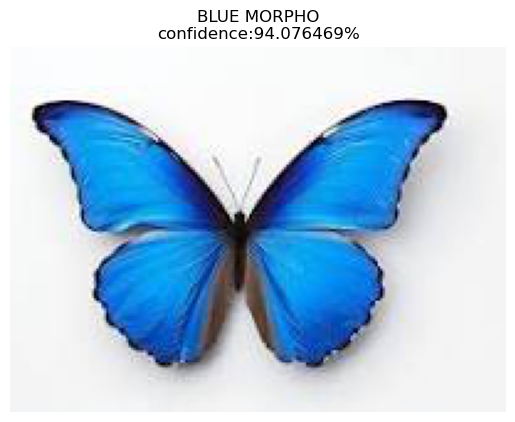

In [42]:
plt.imshow(image)
plt.title(f"{predicted_class}\nconfidence:{confidence:2f}%")
plt.axis("off")
plt.show()
